<a href="https://colab.research.google.com/github/tanmayrathi/ML-PROJECT/blob/main/Decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Decision Tree






In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
file_path = '/content/drive/MyDrive/ML_DATASETS/healthcare-dataset-stroke-data.csv'

In [24]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

In [25]:
df = pd.read_csv(file_path)
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [26]:
df['bmi'].fillna(df['bmi'].mean(), inplace=True)

/tmp/ipykernel_303/3594416367.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].mean(), inplace=True)


In [27]:
le = LabelEncoder()

categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [28]:
df.drop('id', axis=1, inplace=True)

In [29]:
X = df.drop('stroke', axis=1)
y = df['stroke']

In [30]:
!pip install imbalanced-learn

In [31]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X, y = smote.fit_resample(X, y)

In [32]:
for split in [0.3, 0.2]:
    print(f"\n--- Train-Test Split {(1-split)*100:.0f}:{split*100:.0f} ---")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=split, random_state=42
    )

    model = DecisionTreeClassifier(max_depth=5, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))


--- Train-Test Split 70:30 ---
Accuracy: 0.8063078505313679

--- Train-Test Split 80:20 ---
Accuracy: 0.7974293059125964


In [33]:
y_pred = model.predict(X_test)

In [34]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7974293059125964

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.70      0.77       975
           1       0.75      0.90      0.82       970

    accuracy                           0.80      1945
   macro avg       0.81      0.80      0.80      1945
weighted avg       0.81      0.80      0.80      1945


Confusion Matrix:
 [[678 297]
 [ 97 873]]


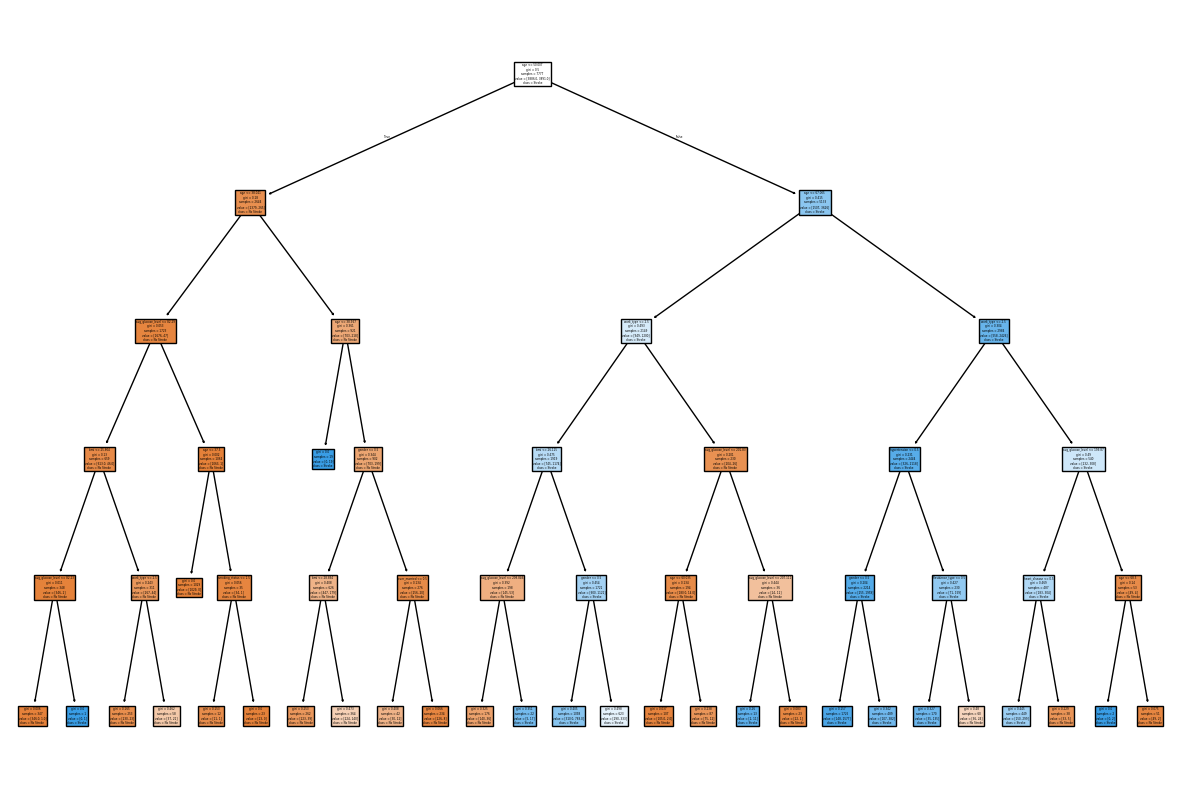

In [35]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15,10))
plot_tree(model, feature_names=X.columns, class_names=['No Stroke', 'Stroke'], filled=True)
plt.show()